# Keras TF 2.0 - Code Along Classification Project

Let's explore a classification task with Keras API for TF 2.0

## The Data

### Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

    :Number of Instances: 569

    :Number of Attributes: 30 numeric, predictive attributes and the class

    :Attribute Information:
        - radius (mean of distances from center to points on the perimeter)
        - texture (standard deviation of gray-scale values)
        - perimeter
        - area
        - smoothness (local variation in radius lengths)
        - compactness (perimeter^2 / area - 1.0)
        - concavity (severity of concave portions of the contour)
        - concave points (number of concave portions of the contour)
        - symmetry 
        - fractal dimension ("coastline approximation" - 1)

        The mean, standard error, and "worst" or largest (mean of the three
        largest values) of these features were computed for each image,
        resulting in 30 features.  For instance, field 3 is Mean Radius, field
        13 is Radius SE, field 23 is Worst Radius.

        - class:
                - WDBC-Malignant
                - WDBC-Benign

    :Summary Statistics:

    ===================================== ====== ======
                                           Min    Max
    ===================================== ====== ======
    radius (mean):                        6.981  28.11
    texture (mean):                       9.71   39.28
    perimeter (mean):                     43.79  188.5
    area (mean):                          143.5  2501.0
    smoothness (mean):                    0.053  0.163
    compactness (mean):                   0.019  0.345
    concavity (mean):                     0.0    0.427
    concave points (mean):                0.0    0.201
    symmetry (mean):                      0.106  0.304
    fractal dimension (mean):             0.05   0.097
    radius (standard error):              0.112  2.873
    texture (standard error):             0.36   4.885
    perimeter (standard error):           0.757  21.98
    area (standard error):                6.802  542.2
    smoothness (standard error):          0.002  0.031
    compactness (standard error):         0.002  0.135
    concavity (standard error):           0.0    0.396
    concave points (standard error):      0.0    0.053
    symmetry (standard error):            0.008  0.079
    fractal dimension (standard error):   0.001  0.03
    radius (worst):                       7.93   36.04
    texture (worst):                      12.02  49.54
    perimeter (worst):                    50.41  251.2
    area (worst):                         185.2  4254.0
    smoothness (worst):                   0.071  0.223
    compactness (worst):                  0.027  1.058
    concavity (worst):                    0.0    1.252
    concave points (worst):               0.0    0.291
    symmetry (worst):                     0.156  0.664
    fractal dimension (worst):            0.055  0.208
    ===================================== ====== ======

    :Missing Attribute Values: None

    :Class Distribution: 212 - Malignant, 357 - Benign

    :Creator:  Dr. William H. Wolberg, W. Nick Street, Olvi L. Mangasarian

    :Donor: Nick Street

    :Date: November, 1995

In [2]:
import pandas as pd
import numpy as np

In [3]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [5]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [6]:
df["benign_0__mal_1"] = data.target

In [7]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


## EDA

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

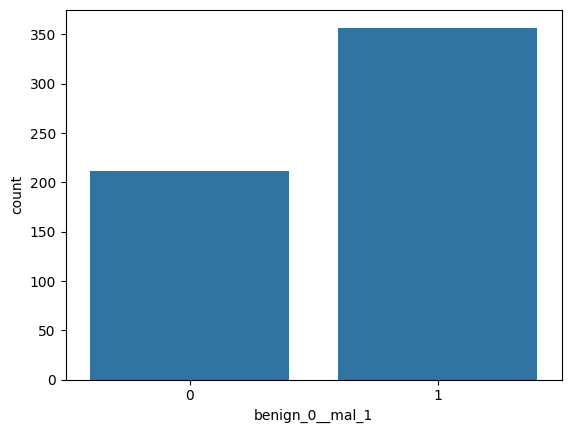

In [9]:
sns.countplot(x='benign_0__mal_1', data=df)
plt.show()

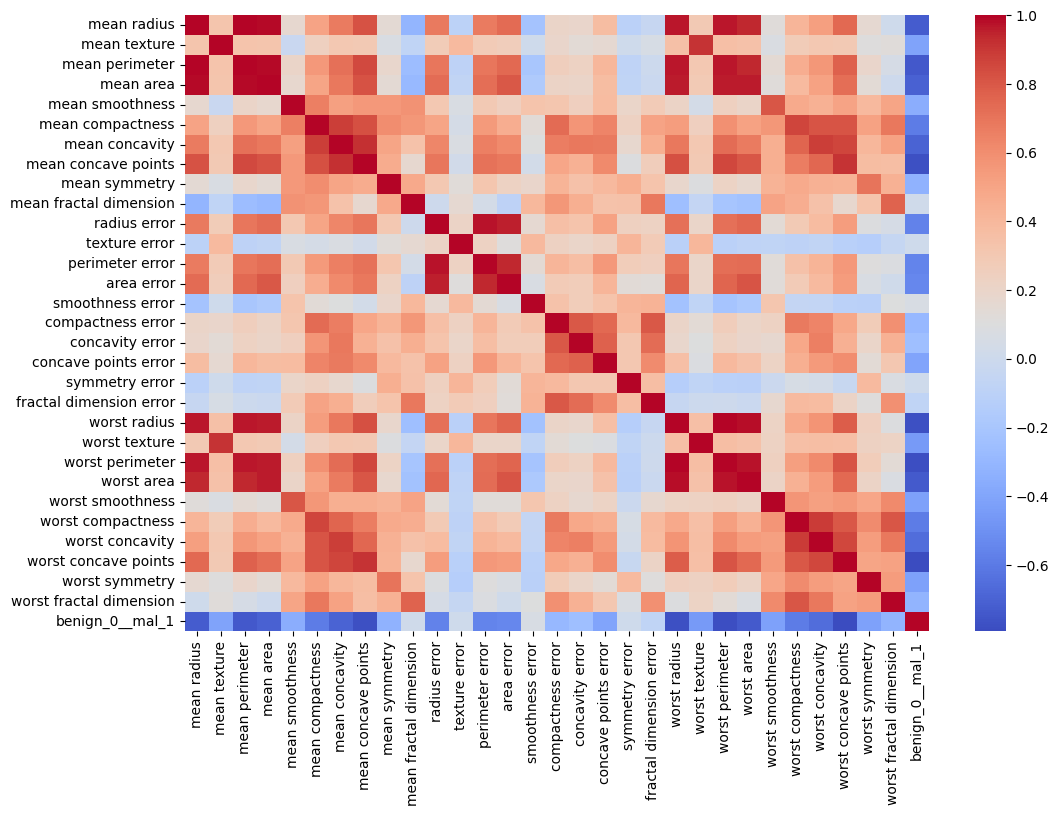

In [10]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), cmap='coolwarm')

plt.show()

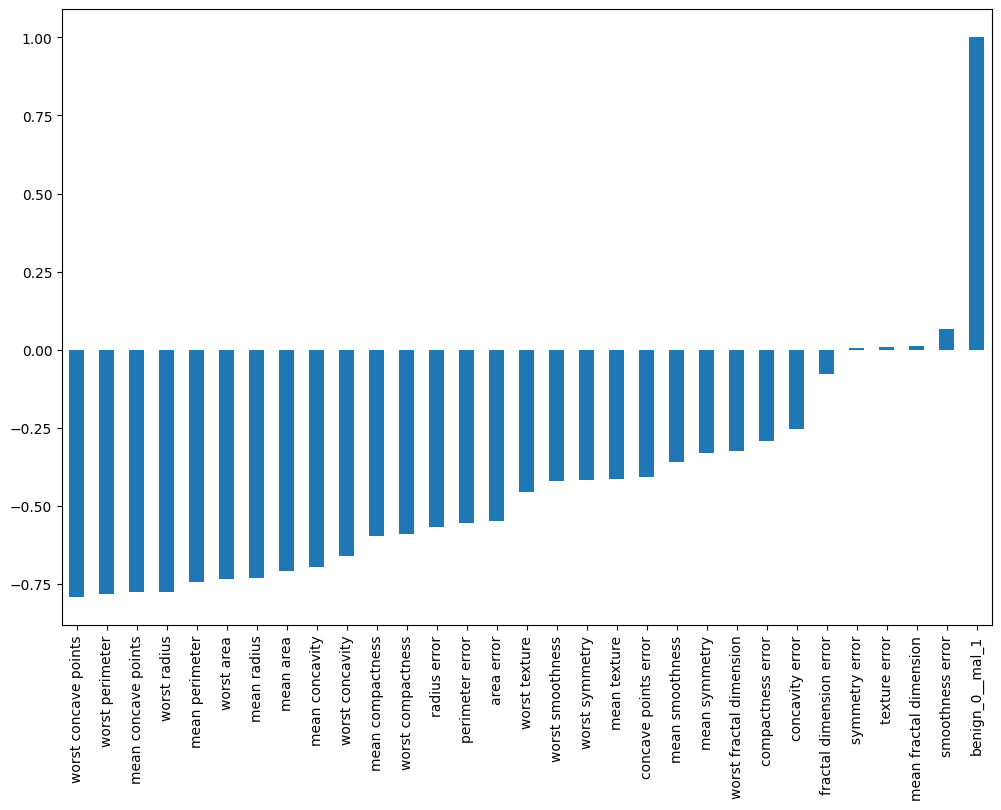

In [11]:
# Based on 'benign_0__mal_1'
df.corr()['benign_0__mal_1'].sort_values().plot(kind='bar', figsize=(12,8))
plt.show()

## Train Test Split

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X = df.drop('benign_0__mal_1', axis=1).values
y = df['benign_0__mal_1'].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=101
)

In [14]:
print(X_train.shape)
print(X_test.shape)

(426, 30)
(143, 30)



## Scaling Data

In [15]:
from sklearn.preprocessing import MinMaxScaler

In [16]:
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Creating the Model

    # For a binary classification problem
    model.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
                  
    

In [17]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation

/Users/slom/Library/Python/3.9/lib/python/site-packages/google/api_core/_python_version_support.py:246: FutureWarning: You are using a non-supported Python version (3.9.6). Google will not post any further updates to google.api_core supporting this Python version. Please upgrade to the latest Python version, or at least Python 3.10, and then update google.api_core.
  warnings.warn(message, FutureWarning)
/Users/slom/Library/Python/3.9/lib/python/site-packages/google/auth/__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
/Users/slom/Library/Python/3.9/lib/python/site-packages/google/oauth2/__init__.py:40: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth wit

In [18]:
model = Sequential()

model.add(Dense(30, activation='relu'))
model.add(Dense(15, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam')

## Training the Model 

### Example One: Choosing too many epochs and overfitting!

In [19]:
model.fit(
    x=X_train,
    y=y_train,
    epochs=600,
    validation_data=(X_test, y_test)
)

Epoch 1/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7237 - val_loss: 0.6847
Epoch 2/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6797 - val_loss: 0.6545
Epoch 3/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6459 - val_loss: 0.6242
Epoch 4/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6161 - val_loss: 0.5865
Epoch 5/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5815 - val_loss: 0.5398
Epoch 6/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5303 - val_loss: 0.4883
Epoch 7/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4877 - val_loss: 0.4346
Epoch 8/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4323 - val_loss: 0.3820
Epoch 9/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3878 - val_loss: 0.3354
Epoch 10/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3544 - val_loss: 0.2957
Epoch 11/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2892 - val_loss: 0.2612
Epoch 12/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2

In [20]:
# model.history.history
losses = pd.DataFrame(model.history.history)

In [21]:
# model_loss
model_loss = pd.DataFrame(model.history.history)

<Axes: >

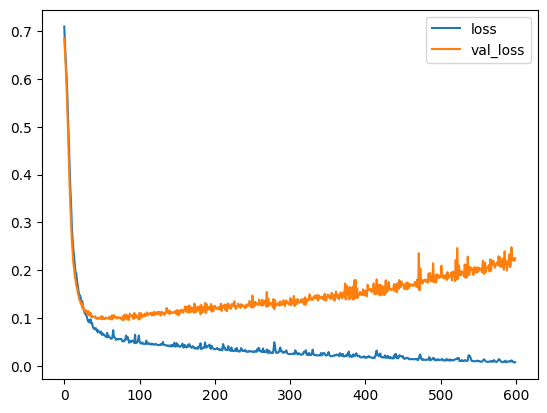

In [22]:
model_loss.plot()


## Example Two: Early Stopping

We obviously trained too much! Let's use early stopping to track the val_loss and stop training once it begins increasing too much!

In [23]:
from tensorflow.keras.callbacks import EarlyStopping

Stop training when a monitored quantity has stopped improving.

    Arguments:
        monitor: Quantity to be monitored.
        min_delta: Minimum change in the monitored quantity
            to qualify as an improvement, i.e. an absolute
            change of less than min_delta, will count as no
            improvement.
        patience: Number of epochs with no improvement
            after which training will be stopped.
        verbose: verbosity mode.
        mode: One of `{"auto", "min", "max"}`. In `min` mode,
            training will stop when the quantity
            monitored has stopped decreasing; in `max`
            mode it will stop when the quantity
            monitored has stopped increasing; in `auto`
            mode, the direction is automatically inferred
            from the name of the monitored quantity.

In [24]:

early_stop = EarlyStopping(
    monitor='val_loss',
    mode='min',
    verbose=1,
    patience=25
)

In [25]:
model = Sequential()

model.add(Dense(30, activation='relu'))
model.add(Dense(15, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam')

In [26]:
model.fit(
    x=X_train,
    y=y_train,
    epochs=600,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/600


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6581 - val_loss: 0.6273
Epoch 2/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6083 - val_loss: 0.5831
Epoch 3/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5676 - val_loss: 0.5389
Epoch 4/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5318 - val_loss: 0.4846
Epoch 5/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4748 - val_loss: 0.4312
Epoch 6/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4152 - val_loss: 0.3798
Epoch 7/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3631 - val_loss: 0.3323
Epoch 8/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3201 - val_loss: 0.2942
Epoch 9/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2920 - val_loss: 0.2599
Epoch 10/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2666 - val_loss: 0.2334
Epoch 11/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2351 - val_loss: 0.2130
Epoch 12/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2265 - val_l

In [27]:
model_loss = pd.DataFrame(model.history.history)

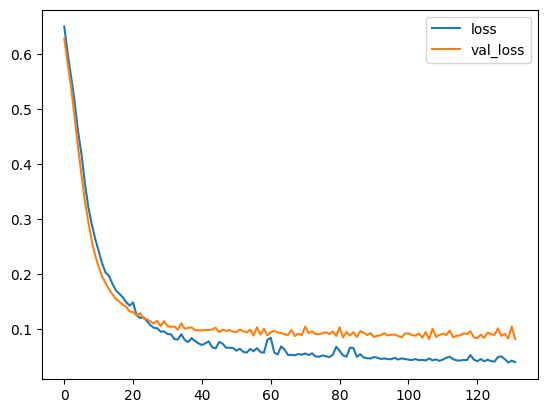

In [28]:
model_loss.plot()
plt.show()

## Example Three: Adding in DropOut Layers

In [39]:
from tensorflow.keras.layers import Dropout

In [40]:
model = Sequential()

model.add(Dense(30, activation='relu'))
model.add(Dropout(0.1))

model.add(Dense(15, activation='relu'))
model.add(Dropout(0.1))

model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam')

In [41]:
model.fit(
    x=X_train,
    y=y_train,
    epochs=600,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.6640 - val_loss: 0.6351
Epoch 2/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6430 - val_loss: 0.6067
Epoch 3/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6023 - val_loss: 0.5719
Epoch 4/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5684 - val_loss: 0.5370
Epoch 5/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5343 - val_loss: 0.4990
Epoch 6/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4918 - val_loss: 0.4609
Epoch 7/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4617 - val_loss: 0.4199
Epoch 8/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4140 - val_loss: 0.3776
Epoch 9/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3791 - val_loss: 0.3417
Epoch 10/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3442 - val_loss: 0.2998
Epoch 11/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3321 - val_loss: 0.2711
Epoch 12/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2

In [42]:
model_loss = pd.DataFrame(model.history.history)

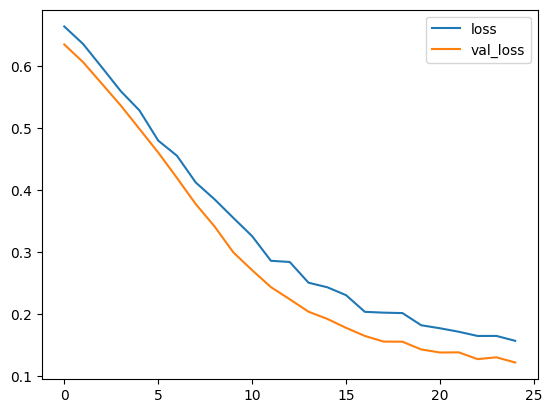

In [43]:
model_loss.plot()
plt.show()

In [44]:
predictions = (model.predict(X_test) > 0.5).astype("int32")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


# Model Evaluation

In [45]:
from sklearn.metrics import classification_report,confusion_matrix

In [46]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97        55
           1       0.98      0.99      0.98        88

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



In [47]:
print(confusion_matrix(y_test, predictions))

[[53  2]
 [ 1 87]]


In [38]:
import joblib
import pickle

# Save scaler
joblib.dump(scaler, "scaler_weights.pkl")

# Save model weights only
model_weights = model.get_weights()

with open("model_weights.pkl", "wb") as f:
    pickle.dump(model_weights, f)

print("Saved: scaler_weights.pkl, model_weights.pkl")

Saved: scaler_weights.pkl, model_weights.pkl
